# Optical Loops: Ring Resonators and Recirculating Fiber Loops

Two devices photonics calls "a loop" turn out to be the SAME linear
feedback system viewed two ways: a **ring resonator** (light physically
circulates in a closed waveguide, coupled in/out once per round trip) and a
**recirculating fiber loop** (a pulse is switched into a fiber spool +
amplifier and sent around N times to synthesize a large effective
dispersion `N*D_per_pass` from a short physical spool -- the real bench
trick for getting two different effective dispersions D1, D2 for this
repo's `dgs.gs_core` two-shot phase retrieval, from ONE fixed spool length,
just by varying the loop count).

Section 3 treats the ring as a single-pole IIR (Z-domain) filter and
verifies -- by literally iterating the round-trip recursion -- that it
converges to Section 1's closed-form steady state, connecting the ring's
finesse to the filter's settling time. Engine: `dgs/optical_loops.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import optical_loops as ol
from dgs import gs_core

print('Setup complete.')


Setup complete.


## 1. Ring Resonator: Through-Port Transmission and Finesse

An all-pass ring resonator's through-port power transmission is
$$T(\phi)=\left|\frac{t-a\,e^{i\phi}}{1-ta\,e^{i\phi}}\right|^2,$$
where `t` is the coupler's self-coupling (field fraction NOT coupled into
the ring), `a` is the single-pass amplitude survival (loss), and `phi` is
the round-trip phase. This is the same Airy-resonance form as a
Fabry-Perot cavity (`dgs.laser_cavity_rlc_analog.cavity_finesse`), with the
two-mirror product `R1*R2` replaced by the one-coupler round-trip product
`t*a`.


t=0.9, a=0.98: finesse F=25.00, FWHM phase=0.2513 rad


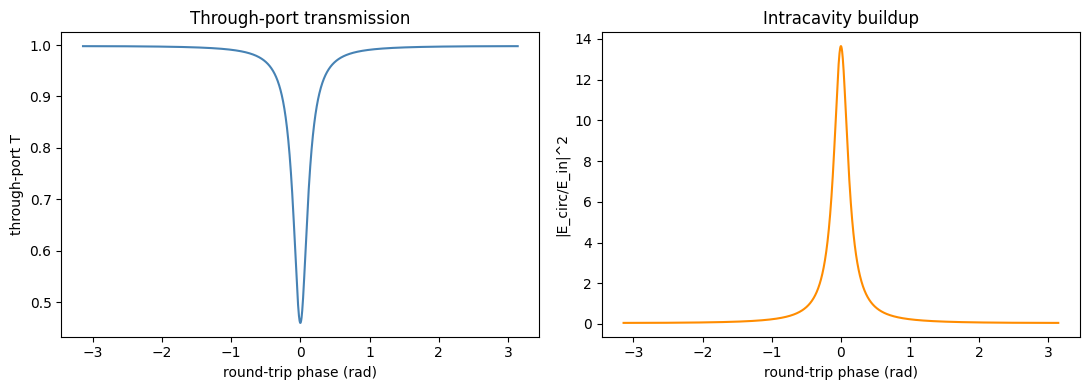

In [2]:
t, a = 0.90, 0.98
phi = np.linspace(-np.pi, np.pi, 2000)
T = ol.through_port_transmission(t, a, phi)
buildup = np.abs(ol.circulating_buildup_factor(t, a, phi))**2

F = ol.ring_finesse(t, a)
fwhm = ol.ring_FWHM_phase(t, a)
print(f't={t}, a={a}: finesse F={F:.2f}, FWHM phase={fwhm:.4f} rad')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(phi, T, color='steelblue')
axes[0].set_xlabel('round-trip phase (rad)'); axes[0].set_ylabel('through-port T')
axes[0].set_title('Through-port transmission')
axes[1].plot(phi, buildup, color='darkorange')
axes[1].set_xlabel('round-trip phase (rad)'); axes[1].set_ylabel('|E_circ/E_in|^2')
axes[1].set_title('Intracavity buildup')
plt.tight_layout()
plt.savefig('optical_loops_ring_spectrum.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Critical Coupling: Checked Numerically

Setting `t = a` should drive the on-resonance through-port transmission to
EXACTLY zero (all input power dissipated in the ring's own loss, none
reflected to the through port) -- confirmed here directly from the
transfer function, not just asserted from the algebra.


In [3]:
for a_val in (0.7, 0.85, 0.99):
    resid = ol.critical_coupling_residual(a_val)
    print(f'  a=t={a_val}: T(phi=0) = {resid:.3e}  (expect ~0)')


  a=t=0.7: T(phi=0) = 0.000e+00  (expect ~0)
  a=t=0.85: T(phi=0) = 0.000e+00  (expect ~0)
  a=t=0.99: T(phi=0) = 0.000e+00  (expect ~0)


## 3. Recirculating Fiber Loop: Dispersion Multiplication

`N` round trips of `D_per_pass` accumulate the SAME total dispersion as one
pass through an `N`-times-longer spool: `D_total = N*D_per_pass`.
`simulate_recirculating_loop` runs this literally -- FFT-based dispersion
each pass via `dgs.gs_core.disperse`, the exact same kernel
`H(nu)=exp(i*pi*D*nu^2)` the rest of this repo's phase-retrieval pipeline
uses -- so a signal built this way is a genuine input to `gs_core`'s
two-measurement GS recovery, just with `D1`, `D2` set by loop COUNT instead
of two different fiber spools.


In [4]:
rng = np.random.default_rng(0)
E0 = np.exp(1j * rng.uniform(0, 2*np.pi, 256))   # unit-amplitude random-phase field

D_per_pass, N = -50.0, 12
D_total = ol.accumulated_dispersion(D_per_pass, N)
print(f'{N} round trips of D={D_per_pass}/pass -> D_total={D_total}')

g_th = ol.loop_threshold_gain_dB(fiber_loss_dB_per_km=0.2, length_km=5.0, coupler_loss_dB=1.0)
print(f'threshold gain to keep the loop lossless per pass: {g_th:.2f} dB')

check = ol.verify_accumulated_dispersion_equals_single_pass(E0, D_per_pass, N)
print(f"N-pass loop == single N*D pass: max_abs_diff={check['max_abs_diff']:.3e}, matches={check['matches']}")


12 round trips of D=-50.0/pass -> D_total=-600.0
threshold gain to keep the loop lossless per pass: 2.00 dB
N-pass loop == single N*D pass: max_abs_diff=6.611e-16, matches=True


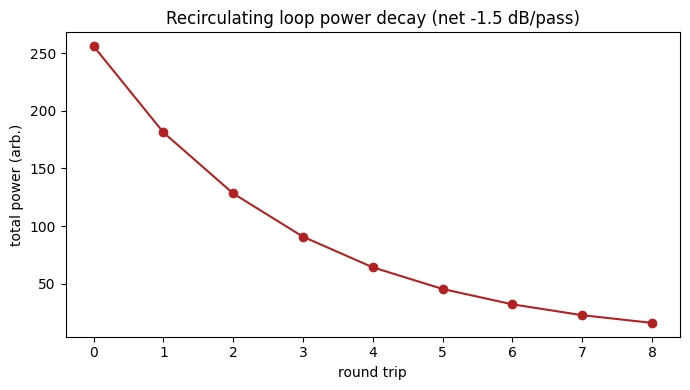

  round trip 0: power = 256.0000
  round trip 1: power = 181.2341
  round trip 2: power = 128.3039
  round trip 3: power = 90.8322
  round trip 4: power = 64.3043
  round trip 5: power = 45.5240
  round trip 6: power = 32.2285
  round trip 7: power = 22.8160
  round trip 8: power = 16.1525


In [5]:
# a lossy loop (amplifier below threshold): power should strictly decay pass-by-pass
snaps = ol.simulate_recirculating_loop(E0, D_per_pass, N=8, net_dB_per_pass=-1.5)
powers = [np.sum(np.abs(s)**2) for s in snaps]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(powers)), powers, 'o-', color='firebrick')
ax.set_xlabel('round trip'); ax.set_ylabel('total power (arb.)')
ax.set_title('Recirculating loop power decay (net -1.5 dB/pass)')
plt.tight_layout()
plt.savefig('optical_loops_power_decay.png', dpi=100, bbox_inches='tight')
plt.show()
for n, p in enumerate(powers):
    print(f'  round trip {n}: power = {p:.4f}')


## 4. The Ring as a Single-Pole IIR (Z-Domain) Filter

The round-trip recursion `E_circ[n] = i*kappa*E_in + z0*E_circ[n-1]`, with
pole `z0 = t*a*e^{i*phi}`, is exactly a single-pole IIR (digital) filter --
`|z0| = t*a < 1` always (since `t,a <= 1`), so the ring is
UNCONDITIONALLY stable, and settles geometrically toward Section 1's
closed-form steady state at a rate set by the SAME `t*a` product that sets
the finesse: high finesse means both a narrow resonance AND a slow-filling
ring.


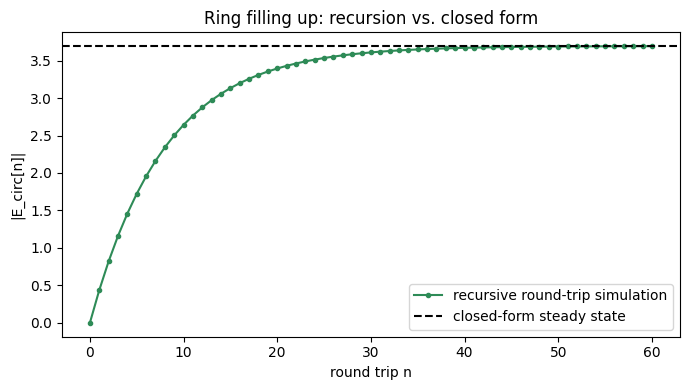

In [6]:
t, a = 0.90, 0.98
E_circ = ol.simulate_ring_buildup_recursion(E_in=1.0, t=t, a=a, phi=0.0, n_round_trips=60)
closed_form = ol.circulating_buildup_factor(t, a, phi=0.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.abs(E_circ), 'o-', ms=3, color='seagreen', label='recursive round-trip simulation')
ax.axhline(abs(closed_form), color='black', ls='--', label='closed-form steady state')
ax.set_xlabel('round trip n'); ax.set_ylabel('|E_circ[n]|')
ax.set_title('Ring filling up: recursion vs. closed form')
ax.legend()
plt.tight_layout()
plt.savefig('optical_loops_iir_buildup.png', dpi=100, bbox_inches='tight')
plt.show()


In [7]:
# lower finesse (t*a smaller) should converge in FEWER round trips than higher finesse
conv_low_F = ol.verify_recursion_converges_to_closed_form(1.0, t=0.5, a=0.9, phi=0.0, n_round_trips=100)
conv_high_F = ol.verify_recursion_converges_to_closed_form(1.0, t=0.95, a=0.99, phi=0.0, n_round_trips=500)

for label, conv in [('low finesse (t=0.5, a=0.9)', conv_low_F), ('high finesse (t=0.95, a=0.99)', conv_high_F)]:
    print(f"{label}: relative_error={conv['relative_error']:.2e}, converged={conv['converged']}, "
          f"settling_round_trips_estimate={conv['settling_round_trips_estimate']:.1f}")


low finesse (t=0.5, a=0.9): relative_error=1.41e-16, converged=True, settling_round_trips_estimate=1.8
high finesse (t=0.95, a=0.99): relative_error=4.65e-14, converged=True, settling_round_trips_estimate=16.8


## 5. Engineering Interpretation

- Section 2's critical-coupling check is the useful "gotcha" in ring
  resonator design: a ring designed with `t != a` NEVER reaches zero
  through-port transmission on resonance no matter how high its finesse
  is -- the coupler and the loss have to be matched, not just the loss
  minimized.
- Section 3's `verify_accumulated_dispersion_equals_single_pass` is the
  actual engineering payoff of a recirculating loop: it is cheaper to build
  ONE short, well-characterized fiber spool + a switch + an amplifier than
  to stock multiple spools of different lengths for different target
  dispersions -- the loop count `N` becomes a purely electronic (switch
  timing) knob on `D_total`, verified here to floating-point precision
  against `dgs.gs_core.disperse` directly rather than assumed.
- Section 4 shows the SAME `t*a` product doing two jobs at once: it sets
  the frequency-domain resonance width (finesse, Section 1) and the
  time-domain settling speed (Section 4) -- a concrete instance of the
  bandwidth/settling-time tradeoff that shows up everywhere from RC
  low-pass filters to PLL loop bandwidth.


## 6. Research Discussion

- This notebook's loop is single-pole (one ring, one delay). A cascade of
  two coupled rings (add-drop -> add-drop) gives a two-pole filter with a
  flatter passband -- would `dgs.gs_core`'s phase-retrieval accuracy
  improve if `D1`, `D2` came from a two-ring cascade's sharper, better-
  separated resonances instead of a single ring's broader Airy lineshape?
- `loop_threshold_gain_dB` mirrors
  `dgs.laser_cavity_rlc_analog.laser_threshold_gain`'s gain-equals-loss
  condition exactly -- but a recirculating loop actively WANTS to sit near
  threshold (net_dB~0) to preserve SNR over many passes, while a laser
  cavity below threshold is just a passive resonator. Worth writing out the
  noise-figure accumulation (ASE buildup per pass) explicitly for the loop
  case, since that -- not the dispersion identity -- is what limits how
  large N can practically get on a real bench.
- Section 4's IIR-filter framing suggests standard Z-domain tools
  (`dgs.causality`'s Kramers-Kronig work, or a bilinear-transform analysis)
  could characterize a MEASURED ring's `(t, a)` directly from its recorded
  step response, rather than from a coupler datasheet.


## 7. Possible Experiments

1. Feed a `simulate_recirculating_loop` output at two different loop counts
   `N1`, `N2` (instead of two different `D` values) into
   `gs_core.retrieve_phase` as the two intensity measurements, and confirm
   phase recovery still converges -- this is the literal bench procedure a
   real recirculating-loop experiment would follow.
2. Sweep `t` at fixed `a` and plot finesse vs. `t` to find the coupling
   that gives a target FWHM bandwidth for a specific application (e.g.
   matching a WDM channel spacing).
3. Extend `round_trip_net_dB` with a simple additive noise-figure model per
   pass, and track SNR (not just power) across `simulate_recirculating_loop`
   snapshots -- addressing the ASE-buildup question raised in Section 6.


## 8. Future Improvements

- `simulate_recirculating_loop` applies a flat per-pass amplitude factor;
  a more realistic model would give the fiber loss and amplifier gain their
  own (possibly wavelength-dependent) transfer functions rather than a
  single scalar dB figure.
- `iir_pole_from_ring` only handles a single ring; a `RingCascade` class
  chaining several `(t_i, a_i, phi_i)` stages (each contributing its own
  pole) would let this module model real multi-ring add-drop filters used
  in WDM devices.
